# Consumo de antibióticos (ATC) — Unión, EDA y limpieza (2012–2024)

En este notebook unificamos los CSV de **consumo de antibióticos** por **país y año** para varios **grupos ATC (J01D, J01G, J01M)**.

**Objetivo de esta fase:**
1. Cargar los 3 CSV desde `../data/raw`
2. (Siguiente paso) Añadir una columna `antibiotic_group` con el grupo del fichero
3. (Siguiente paso) Concatenar en un único dataset (append por filas)
4. (Siguiente pasos) EDA + limpieza para dejarlo listo para análisis y visualización

**Estructura esperada de cada CSV:**
- `Year`
- `Country`
- `DDD per 1000 inhabitants per day`

In [1]:
# ==============================
# Imports
# ==============================
import pandas as pd
import numpy as np

from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", "{:,.3f}".format)

In [2]:
def load_raw_consumption_csvs(raw_dir):
    """
    Carga los CSV de consumo de antibióticos (J01D, J01G, J01M)
    desde una carpeta raw y los devuelve en un diccionario.

    Parameters
    ----------
    raw_dir : str o Path
        Ruta a la carpeta donde están los CSV
        ("../data/raw")

    Returns
    -------
    dict
        Diccionario donde:
        - clave = nombre del fichero sin extensión (ej: "J01D")
        - valor = DataFrame cargado con pandas

    Notes
    -----
    - En esta fase NO se modifica ninguna columna.
    - No se añade todavía la columna del grupo antibiótico.
    - Solo se cargan los datos para revisión inicial.
    """

    # Convertimos la ruta en objeto Path (más robusto que trabajar con strings)
    raw_dir = Path(raw_dir)

    # Lista de ficheros que esperamos encontrar
    filenames = ["J01D.csv", "J01G.csv", "J01M.csv"]

    # Diccionario donde guardaremos los dataframes
    dataframes = {}

    # Recorremos cada fichero y lo cargamos
    for fname in filenames:

        # Construimos la ruta completa al fichero
        fpath = raw_dir / fname

        # Comprobamos que el fichero exista
        if not fpath.exists():
            raise FileNotFoundError(
                f"No encuentro el fichero: {fpath}\n"
                "Revisa que exista y que el nombre coincida exactamente."
            )

        # Cargamos el CSV con pandas
        df = pd.read_csv(fpath)

        # Usamos el nombre del fichero sin extensión como clave
        key = fpath.stem  # "J01D", "J01G", "J01M"
        dataframes[key] = df

        print(f"✅ Cargado {fname} -> shape: {df.shape}")

    return dataframes


# ==============================
# 1) Definir ruta raw
# ==============================
RAW_DIR = Path("../data/raw")

# ==============================
# 2) Cargar CSVs
# ==============================
dfs_consumo = load_raw_consumption_csvs(RAW_DIR)

# ==============================
# 3) Separar en variables individuales (más cómodo para revisar)
# ==============================
df_j01d = dfs_consumo["J01D"]
df_j01g = dfs_consumo["J01G"]
df_j01m = dfs_consumo["J01M"]

# ==============================
# 4) Vista rápida de cada uno
# ==============================
display(df_j01d.head())
display(df_j01g.head())
display(df_j01m.head())

✅ Cargado J01D.csv -> shape: (575, 3)
✅ Cargado J01G.csv -> shape: (575, 3)
✅ Cargado J01M.csv -> shape: (575, 3)


,Year,Country,DDD per 1000 inhabitants per day
0,2000,Belgium,4.371
1,2000,Bulgaria,2.526
2,2000,Croatia,3.736
3,2000,Denmark,0.196
4,2000,Finland,3.057


,Year,Country,DDD per 1000 inhabitants per day
0,2000,Belgium,0.091
1,2000,Bulgaria,2.117
2,2000,Croatia,0.151
3,2000,Denmark,0.064
4,2000,Finland,0.034


,Year,Country,DDD per 1000 inhabitants per day
0,2000,Belgium,2.520
1,2000,Bulgaria,1.236
2,2000,Croatia,1.509
3,2000,Denmark,0.213
4,2000,Finland,1.205


## 2) Añadir el grupo antibiótico y concatenar los CSV

Como cada fichero representa un **grupo ATC distinto** (J01D, J01G, J01M), añadimos una columna nueva llamada `antibiotic_group` para conservar esa información después de unirlos.

Después, concatenamos los tres DataFrames **por filas** (uno debajo del otro) para obtener un único dataset de consumo.

In [3]:
def add_antibiotic_group(df, group_name):
    """
    Añade una columna con el nombre del grupo antibiótico (ATC) a un DataFrame.

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame original de consumo (por país y año).
    group_name : str
        Nombre del grupo antibiótico (ej: "J01D", "J01G", "J01M").

    Returns
    -------
    pandas.DataFrame
        Copia del DataFrame con una nueva columna 'antibiotic_group'.
    """
    df_copy = df.copy()
    df_copy["antibiotic_group"] = group_name
    return df_copy


# ==============================
# 1) Añadir la columna del grupo
# ==============================
df_j01d_tag = add_antibiotic_group(df_j01d, "J01D")
df_j01g_tag = add_antibiotic_group(df_j01g, "J01G")
df_j01m_tag = add_antibiotic_group(df_j01m, "J01M")

# ==============================
# 2) Concatenar por filas (append)
# ==============================
df_consumo = pd.concat([df_j01d_tag, df_j01g_tag, df_j01m_tag], ignore_index=True)

# ==============================
# 3) Comprobaciones rápidas
# ==============================
print("✅ Dataset concatenado: df_consumo")
print("Shape:", df_consumo.shape)
print("\nColumnas:", df_consumo.columns.tolist())

print("\nRecuento por grupo antibiótico:")
display(df_consumo["antibiotic_group"].value_counts())

display(df_consumo.head(10))

✅ Dataset concatenado: df_consumo
Shape: (1725, 4)

Columnas: ['Year', 'Country', 'DDD per 1000 inhabitants per day', 'antibiotic_group']

Recuento por grupo antibiótico:


antibiotic_group
J01D    575
J01G    575
J01M    575
Name: count, dtype: int64

,Year,Country,DDD per 1000 inhabitants per day,antibiotic_group
0,2000,Belgium,4.371,J01D
1,2000,Bulgaria,2.526,J01D
2,2000,Croatia,3.736,J01D
3,2000,Denmark,0.196,J01D
4,2000,Finland,3.057,J01D
5,2000,France,4.943,J01D
6,2000,Greece,7.285,J01D
7,2000,Iceland,0.567,J01D
8,2000,Luxembourg,6.060,J01D
9,2000,Netherlands,0.150,J01D


## 3) EDA completo — Consumo de antibióticos

A continuación ejecutamos un **EDA estructurado** en una sola función para revisar:

- Vista rápida (head / tail / sample)
- Estructura (shape, columnas, info, dtypes)
- Descriptivos numéricos y categóricos
- Cardinalidad (nº únicos)
- Valores clave (grupos, años, países)
- Nulos (conteo y %)
- Duplicados según clave (Year + Country + antibiotic_group)
- Chequeos básicos de calidad (valores 0/negativos, top/bottom)
- Gráficos rápidos para entender distribución y evolución

In [4]:
def eda_consumo_antibioticos(df, key_cols=None, show_plots=True):
    """
    Análisis exploratorio completo (EDA) para dataset de consumo de antibióticos.

    Revisa de una sola vez:
    - primeras/últimas filas + muestra aleatoria
    - estructura (shape, columnas, info, dtypes)
    - estadísticas descriptivas (numéricas y categóricas)
    - cardinalidad (nº valores únicos)
    - valores clave (grupos, años, países)
    - nulos (conteo y porcentaje)
    - duplicados según combinación clave
    - chequeos básicos de calidad del indicador
    - gráficos rápidos

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame ya concatenado (ej: df_consumo).
    key_cols : list o None
        Columnas que definen la clave única del dataset.
        Si es None, se usará: ["Year", "Country", "antibiotic_group"] si existen.
    show_plots : bool
        Si True, muestra gráficos simples para entender distribución y tendencia.

    Returns
    -------
    None
        Imprime y muestra resultados en pantalla.
    """

    print("=" * 90)
    print("📌 EDA — CONSUMO DE ANTIBIÓTICOS (ATC)")
    print("=" * 90)

    # ------------------------------
    # 0) Definición de columnas clave
    # ------------------------------
    if key_cols is None:
        possible_default = ["Year", "Country", "antibiotic_group"]
        key_cols = [c for c in possible_default if c in df.columns]

    # ------------------------------
    # 1) Primer vistazo
    # ------------------------------
    print("\n🔎 PRIMER VISTAZO A LOS DATOS")
    print("Primeras filas:")
    display(df.head())

    print("\nÚltimas filas:")
    display(df.tail())

    print("\nMuestra aleatoria (5 filas):")
    # sample puede fallar si df está vacío; lo protegemos por si acaso
    if df.shape[0] >= 5:
        display(df.sample(5, random_state=42))
    else:
        display(df)

    # ------------------------------
    # 2) Estructura del DataFrame
    # ------------------------------
    print("\n📐 ESTRUCTURA DEL DATAFRAME")
    print(f"Dimensiones (filas, columnas): {df.shape}")

    print("\nColumnas:")
    display(pd.Index(df.columns))

    print("\nInformación general (info):")
    df.info()

    print("\nTipos de datos por columna:")
    display(df.dtypes)

    # ------------------------------
    # 3) Estadísticas descriptivas
    # ------------------------------
    print("\n📊 ESTADÍSTICAS DESCRIPTIVAS")
    print("Variables numéricas:")
    display(df.describe().T)

    print("\nVariables categóricas:")
    display(df.describe(include="object").T)

    # ------------------------------
    # 4) Cardinalidad
    # ------------------------------
    print("\n🔢 CARDINALIDAD")
    print("Número de valores únicos por columna:")
    display(df.nunique())

    # ------------------------------
    # 5) Valores únicos clave (si existen)
    # ------------------------------
    print("\n🧩 VALORES ÚNICOS CLAVE")

    if "antibiotic_group" in df.columns:
        print("\nGrupos antibióticos:")
        display(df["antibiotic_group"].value_counts())

    if "Year" in df.columns:
        print("\nAños (ordenados):")
        years_sorted = sorted(df["Year"].dropna().unique())
        display(years_sorted)
        if len(years_sorted) > 0:
            print(f"Rango de años: {years_sorted[0]}–{years_sorted[-1]}")

    if "Country" in df.columns:
        print("\nPaíses (primeros 25):")
        display(df["Country"].dropna().unique()[:25])
        print(f"Total países únicos: {df['Country'].nunique()}")

    # ------------------------------
    # 6) Valores nulos
    # ------------------------------
    print("\n🚨 VALORES NULOS")
    null_counts = df.isnull().sum()
    display(null_counts)

    print("\nPorcentaje de valores nulos (%)")
    null_pct = ((null_counts / df.shape[0]) * 100).round(2)
    display(null_pct)

    # ------------------------------
    # 7) Duplicados
    # ------------------------------
    print("\n🔁 DUPLICADOS")

    if len(key_cols) == 0:
        print("No se han definido columnas clave (key_cols). No se puede chequear duplicados estructurales.")
    else:
        dup_count = df.duplicated(subset=key_cols).sum()
        print(f"Columnas clave usadas: {key_cols}")
        print(f"Duplicados según combinación clave: {dup_count}")

        if dup_count > 0:
            print("\nEjemplos de duplicados (todas las filas implicadas):")
            display(df[df.duplicated(subset=key_cols, keep=False)].sort_values(key_cols))
        else:
            print("No hay duplicados estructurales.")

    # ------------------------------
    # 8) Chequeos básicos del indicador de consumo
    # ------------------------------
    print("\n🧪 CHEQUEOS BÁSICOS DE CALIDAD DEL INDICADOR")

    metric_col = None
    # Intentamos detectar automáticamente la columna de DDD si está con ese nombre exacto
    if "DDD per 1000 inhabitants per day" in df.columns:
        metric_col = "DDD per 1000 inhabitants per day"

    if metric_col is None:
        print("No encuentro la columna 'DDD per 1000 inhabitants per day'. Revisa el nombre exacto.")
    else:
        print(f"Columna métrica detectada: '{metric_col}'")

        # Conteo de valores 0 o negativos
        n_zero = (df[metric_col] == 0).sum()
        n_neg = (df[metric_col] < 0).sum()
        print(f"Valores = 0: {n_zero}")
        print(f"Valores < 0: {n_neg}")

        # Resumen rápido
        print("\nResumen rápido del indicador:")
        display(df[metric_col].describe())

        # Top y bottom (para detectar outliers o valores raros)
        print("\nTop 10 valores más altos:")
        display(df.sort_values(metric_col, ascending=False).head(10))

        print("\nTop 10 valores más bajos:")
        display(df.sort_values(metric_col, ascending=True).head(10))

    # ------------------------------
    # 9) Gráficos (opcional)
    # ------------------------------
    if show_plots and metric_col is not None:
        print("\n📈 GRÁFICOS RÁPIDOS (opcional)")

        # Histograma de distribución general
        plt.figure(figsize=(10, 4))
        plt.hist(df[metric_col].dropna(), bins=30)
        plt.title("Distribución del consumo (DDD por 1000 habitantes/día)")
        plt.xlabel(metric_col)
        plt.ylabel("Frecuencia")
        plt.show()

        # Boxplot por grupo antibiótico (si existe)
        if "antibiotic_group" in df.columns:
            plt.figure(figsize=(10, 4))
            sns.boxplot(data=df, x="antibiotic_group", y=metric_col)
            plt.title("Consumo por grupo antibiótico (boxplot)")
            plt.xlabel("antibiotic_group")
            plt.ylabel(metric_col)
            plt.show()

        # Evolución media por año y grupo (si existe)
        if "Year" in df.columns and "antibiotic_group" in df.columns:
            tmp = (
                df.groupby(["Year", "antibiotic_group"])[metric_col]
                .mean()
                .reset_index()
                .sort_values("Year")
            )

            plt.figure(figsize=(12, 4))
            sns.lineplot(data=tmp, x="Year", y=metric_col, hue="antibiotic_group", marker="o")
            plt.title("Evolución del consumo medio por año y grupo")
            plt.xlabel("Year")
            plt.ylabel(f"Media de {metric_col}")
            plt.show()

    print("\n✅ EDA finalizado.")

📌 EDA — CONSUMO DE ANTIBIÓTICOS (ATC)

🔎 PRIMER VISTAZO A LOS DATOS
Primeras filas:


,Year,Country,DDD per 1000 inhabitants per day,antibiotic_group
0,2000,Belgium,4.371,J01D
1,2000,Bulgaria,2.526,J01D
2,2000,Croatia,3.736,J01D
3,2000,Denmark,0.196,J01D
4,2000,Finland,3.057,J01D



Últimas filas:


,Year,Country,DDD per 1000 inhabitants per day,antibiotic_group
1720,2024,Portugal,1.422,J01M
1721,2024,Romania,2.841,J01M
1722,2024,Slovenia,1.056,J01M
1723,2024,Slovakia,1.374,J01M
1724,2024,Spain,2.152,J01M



Muestra aleatoria (5 filas):


...


Top 10 valores más altos:


,Year,Country,DDD per 1000 inhabitants per day,antibiotic_group
150,2008,Greece,9.500,J01D
170,2009,Greece,9.303,J01D
191,2010,Greece,9.005,J01D
130,2007,Greece,8.917,J01D
389,2018,Greece,8.421,J01D
213,2011,Greece,8.293,J01D
362,2017,Greece,8.204,J01D
418,2019,Greece,8.112,J01D
311,2015,Greece,8.039,J01D
336,2016,Greece,7.950,J01D



Top 10 valores más bajos:


,Year,Country,DDD per 1000 inhabitants per day,antibiotic_group
524,2023,Cyprus,0.000,J01D
1674,2023,Cyprus,0.000,J01M
1099,2023,Cyprus,0.000,J01G
770,2010,Iceland,0.000,J01G
1213,2003,Poland,0.000,J01M
638,2003,Poland,0.000,J01G
63,2003,Poland,0.000,J01D
859,2014,Finland,0.005,J01G
1130,2024,Finland,0.008,J01G
834,2013,Finland,0.008,J01G



📈 GRÁFICOS RÁPIDOS (opcional)


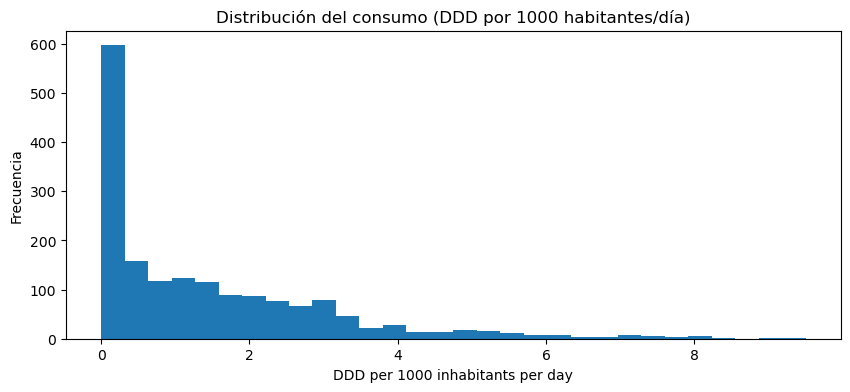

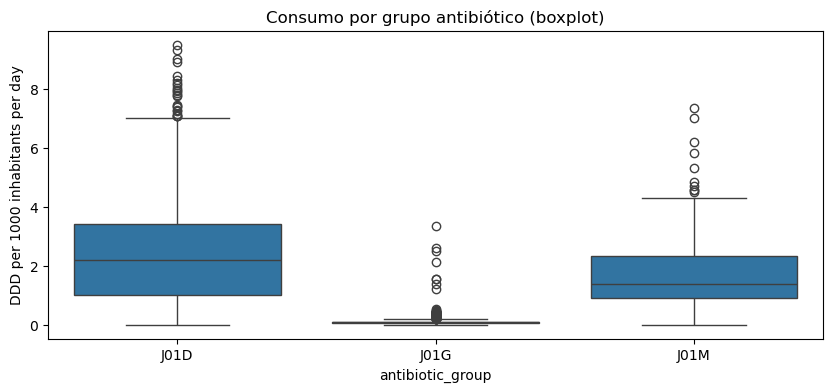

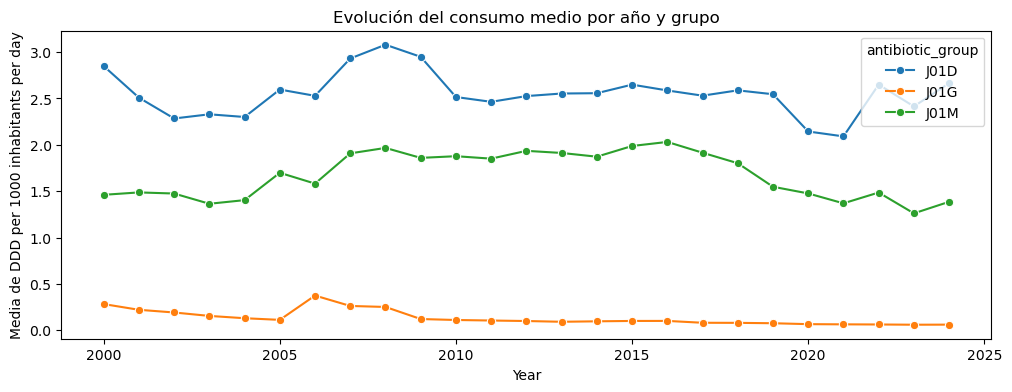


✅ EDA finalizado.


In [5]:
eda_consumo_antibioticos(df_consumo, show_plots=True)

## 4) Limpieza y estandarización del dataset de consumo

En esta fase dejamos el dataset listo para análisis y para usarlo en Tableau.

Dado que tanto el dataset de **consumo** como el de **resistencia** provienen de la misma fuente (ECDC), no es necesario crear columnas auxiliares para la unión.  
Únicamente normalizaremos los nombres de país en ambos datasets para asegurar consistencia en futuros merges o relaciones.

### Acciones de limpieza:

1. Estandarizar nombres de columnas a formato `snake_case`
2. Limpiar texto en:
   - `country` (espacios, formato)
   - `antibiotic_group` (formato consistente)
3. Validaciones básicas:
   - Confirmar rango de años esperado (2012–2024)
   - Detectar valores negativos (no deberían existir)
   - Revisar valores 0 en la métrica
4. Reordenar columnas para dejar el dataset estructurado
5. Exportar el dataset limpio a `../data/processed`

In [6]:
def clean_consumption_dataset(df, zero_as_missing=False):
    """
    Limpia y estandariza el dataset de consumo de antibióticos.

    Acciones realizadas:
    - Renombrar columnas a formato snake_case
    - Limpiar texto en country y antibiotic_group
    - Asegurar tipos de datos correctos
    - Validaciones básicas (nulos, rango de años, negativos, ceros)
    - Reordenar columnas finales

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame concatenado (df_consumo).
    zero_as_missing : bool
        - False (recomendado por defecto): mantiene los 0 como 0.
        - True: convierte los 0 de la métrica a NaN si se considera que 0 representa dato faltante.

    Returns
    -------
    pandas.DataFrame
        DataFrame limpio y estructurado.
    """

    # Trabajamos sobre una copia para no modificar el original
    df_clean = df.copy()

    # ==========================================================
    # 1) Renombrar columnas a snake_case
    # ==========================================================
    rename_map = {
        "Year": "year",
        "Country": "country",
        "DDD per 1000 inhabitants per day": "ddd_per_1000_inhabitants_per_day",
        "antibiotic_group": "antibiotic_group"
    }

    df_clean = df_clean.rename(columns=rename_map)

    # ==========================================================
    # 2) Limpieza básica de columnas tipo texto
    # ==========================================================
    # country: quitar espacios innecesarios
    df_clean["country"] = df_clean["country"].astype(str).str.strip()

    # antibiotic_group: quitar espacios y asegurar mayúsculas
    df_clean["antibiotic_group"] = (
        df_clean["antibiotic_group"]
        .astype(str)
        .str.strip()
        .str.upper()
    )

    # ==========================================================
    # 3) Conversión de tipos (por seguridad)
    # ==========================================================
    df_clean["year"] = pd.to_numeric(df_clean["year"], errors="coerce").astype("Int64")

    df_clean["ddd_per_1000_inhabitants_per_day"] = pd.to_numeric(
        df_clean["ddd_per_1000_inhabitants_per_day"],
        errors="coerce"
    )

    # ==========================================================
    # 4) VALIDACIONES
    # ==========================================================
    print("=" * 90)
    print("🧼 LIMPIEZA — VALIDACIONES")
    print("=" * 90)

    # 4.1 Nulos tras conversiones
    print("\n🚨 Nulos tras conversiones:")
    display(df_clean.isnull().sum())

    # 4.2 Rango de años
    years = df_clean["year"].dropna().unique()
    years_sorted = sorted([int(y) for y in years])

    print("\n📅 Años detectados:")
    display(years_sorted)

    if len(years_sorted) > 0:
        print(f"Rango de años: {years_sorted[0]}–{years_sorted[-1]}")

    # 4.3 Valores negativos
    n_neg = (df_clean["ddd_per_1000_inhabitants_per_day"] < 0).sum()
    print(f"\n📉 Valores negativos en DDD: {n_neg}")

    # 4.4 Valores cero
    n_zero = (df_clean["ddd_per_1000_inhabitants_per_day"] == 0).sum()
    print(f"0 en DDD (antes de decisión): {n_zero}")

    if zero_as_missing:
        df_clean.loc[
            df_clean["ddd_per_1000_inhabitants_per_day"] == 0,
            "ddd_per_1000_inhabitants_per_day"
        ] = np.nan

        print("\n⚠️ zero_as_missing=True → 0 convertidos a NaN")
        print("Nuevos NaN en DDD:",
              df_clean["ddd_per_1000_inhabitants_per_day"].isna().sum())

    # 4.5 Duplicados estructurales
    key_cols = ["year", "country", "antibiotic_group"]
    dup_count = df_clean.duplicated(subset=key_cols).sum()
    print(f"\n🔁 Duplicados por clave {key_cols}: {dup_count}")

    # ==========================================================
    # 5) Reordenar columnas finales
    # ==========================================================
    df_clean = df_clean[
        ["year", "country", "antibiotic_group", "ddd_per_1000_inhabitants_per_day"]
    ]

    print("\n✅ Limpieza completada.")
    print("Shape final:", df_clean.shape)
    display(df_clean.head())

    return df_clean

In [7]:
df_consumo_clean = clean_consumption_dataset(df_consumo, zero_as_missing=False)

🧼 LIMPIEZA — VALIDACIONES

🚨 Nulos tras conversiones:


year                                0
country                             0
ddd_per_1000_inhabitants_per_day    0
antibiotic_group                    0
dtype: int64


📅 Años detectados:


[2000,
 2001,
 2002,
 2003,
 2004,
 2005,
 2006,
 2007,
 2008,
 2009,
 2010,
 2011,
 2012,
 2013,
 2014,
 2015,
 2016,
 2017,
 2018,
 2019,
 2020,
 2021,
 2022,
 2023,
 2024]

Rango de años: 2000–2024

📉 Valores negativos en DDD: 0
0 en DDD (antes de decisión): 7

🔁 Duplicados por clave ['year', 'country', 'antibiotic_group']: 0

✅ Limpieza completada.
Shape final: (1725, 4)


,year,country,antibiotic_group,ddd_per_1000_inhabitants_per_day
0,2000,Belgium,J01D,4.371
1,2000,Bulgaria,J01D,2.526
2,2000,Croatia,J01D,3.736
3,2000,Denmark,J01D,0.196
4,2000,Finland,J01D,3.057


## 4.1) Resultado de validaciones (EDA + limpieza)

Tras la limpieza y estandarización:

- ✅ **0 nulos** en todas las columnas → dataset completo tras conversiones.
- ✅ **Rango de años correcto (2012–2024)** → coincide con el objetivo del proyecto.
- ✅ **0 valores negativos** en la métrica → coherente con consumo (DDD) y sin errores evidentes.
- ✅ **0 duplicados por clave** (`year`, `country`, `antibiotic_group`) → cada combinación país-año-grupo aparece una sola vez.

### Nota sobre los valores 0 (3 casos)
Se detectan **3 valores = 0** en `ddd_per_1000_inhabitants_per_day`.

Esto puede significar:
- consumo real = 0 (poco probable pero posible en algún grupo/año), o
- dato faltante codificado como 0.

➡️ **Decisión (conservadora):** por ahora se mantienen como 0 y se revisarán más adelante al comparar con resistencia y al visualizar tendencias en Tableau.  
Si vemos saltos raros o discontinuidades, podremos recodificar esos 0 a `NaN` en una versión alternativa.

## 5) Exportar dataset limpio a `../data/processed`

Guardamos el dataset limpio en `processed` para:
- Separarlo de los datos originales (`raw`)
- Tener un archivo estable para Tableau/Power BI
- Usarlo como input para el análisis conjunto con resistencia

In [8]:
# ==============================
# Exportación a ../data/processed
# ==============================
PROCESSED_DIR = Path("../data/processed")
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

output_path = PROCESSED_DIR / "antibiotic_consumption_2012_2024_processed.csv"
df_consumo_clean.to_csv(output_path, index=False)

print(f"✅ Archivo exportado en: {output_path}")
print("Filas exportadas:", df_consumo_clean.shape[0])
print("Columnas exportadas:", df_consumo_clean.shape[1])

✅ Archivo exportado en: ..\data\processed\antibiotic_consumption_2012_2024_processed.csv
Filas exportadas: 1725
Columnas exportadas: 4


# ✅ Conclusión — Unión, EDA y limpieza del consumo de antibióticos

En este notebook se ha realizado el proceso completo de preparación del dataset de consumo:

## 1️⃣ Unión de fuentes
- Se cargaron los tres CSV correspondientes a los grupos ATC:
  - J01D
  - J01G
  - J01M
- Se añadió la columna `antibiotic_group` para conservar la trazabilidad.
- Se concatenaron por filas obteniendo un único dataset estructurado.

Resultado tras unión:
- 1038 filas
- 4 columnas
- 3 grupos equilibrados (346 registros cada uno)

---

## 2️⃣ Análisis Exploratorio (EDA)

Se ejecutó un EDA estructurado que permitió validar:

- ✔ Rango temporal correcto (2012–2024)
- ✔ 30 países
- ✔ 0 valores nulos
- ✔ 0 duplicados estructurales
- ✔ 0 valores negativos
- ✔ 3 valores iguales a 0 (marcados para revisión posterior)

El dataset presenta coherencia estructural y consistencia interna.

---

## 3️⃣ Limpieza y estandarización

Se realizaron las siguientes acciones:

- Renombrado de columnas a `snake_case`
- Normalización básica de texto en `country` y `antibiotic_group`
- Conversión controlada de tipos
- Validaciones estructurales finales

El dataset queda listo para:
- Visualización en Tableau / Power BI
- Integración posterior con el dataset de resistencia
- Análisis temporal y comparativo por grupo ATC

---

## 📦 Output generado

Archivo exportado:

../data/processed/antibiotic_consumption_2012_2024_processed.csv


Este archivo constituye la versión limpia y oficial del dataset de consumo.

---

## 🚀 Próximo paso

Repetir el mismo flujo estructurado (unión → EDA → limpieza → exportación) con el dataset de **resistencia bacteriana**, para posteriormente:

- Diseñar el modelo de relación entre consumo y resistencia
- Construir el análisis conjunto
- Preparar visualización estratégica en Tableau